# Physique des marchés
## TP3.3 : Nature des jeux et délais

### Par : Adonis JAMAL

#### Buts

1. Etudier l’impact du délai dans les récompenses sur la dynamique des modèles
2. Comparer la dynamique du jeu de la minorité et majorité avec délais

Reprendre le code du TP3.2 pour le jeu de la minorité à nombre de spéculateurs variable et mémoire de score finie; il faut que les $\mu$ encodent les derniers $M$ signes de $A$ (pas d'évolution aléatoire).

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numba import njit
from tqdm import tqdm

np.random.seed(0)

---
### 1. Jeu de la minorité : prédictions avec délais

1. Généraliser le code pour inclure un délai entre la décision et la récompense : le spectateur $i$ joue $n_i(t) a_{i, \mu_i(t)}$ et $A(t) = \Omega_{\mu(t)} + \sum_i n_i(t) a_{i, \mu_i(t)}$ mais l'évolution de son score est $$U_i (t+1) = U_i(t) (1-\lambda) + \lambda (-a_{i, \mu_i(t-d)} A(t) - \epsilon)$$ 

In [9]:
@njit
def run_minority_delay(a, Omega, U, mu_init, P, epsilon, lam, d, T):
    N_s = a.shape[0]
    A_hist = np.empty(T)
    mu_hist = np.empty(T, dtype=np.int64)
    mu = mu_init

    for t in range(T):
        n = (U >= 0).astype(np.float64)
        A_t = Omega[mu] + np.sum(n * a[:, mu])
        A_hist[t] = A_t
        mu_hist[t] = mu

        if t >= d:
            mu_delayed = mu_hist[t - d]
        else:
            mu_delayed = mu_init

        U[:] = (1 - lam) * U + lam * (-a[:, mu_delayed] * A_t - epsilon)
        mu = (2 * mu + int(A_t > 0)) % P

    return A_hist, mu_hist, U, mu

2. Tracer $A(t)$ en fonction de $t$ pour $d=0,1,2,3,4$ et commenter.

Running simulations: 5it [00:05,  1.17s/it]


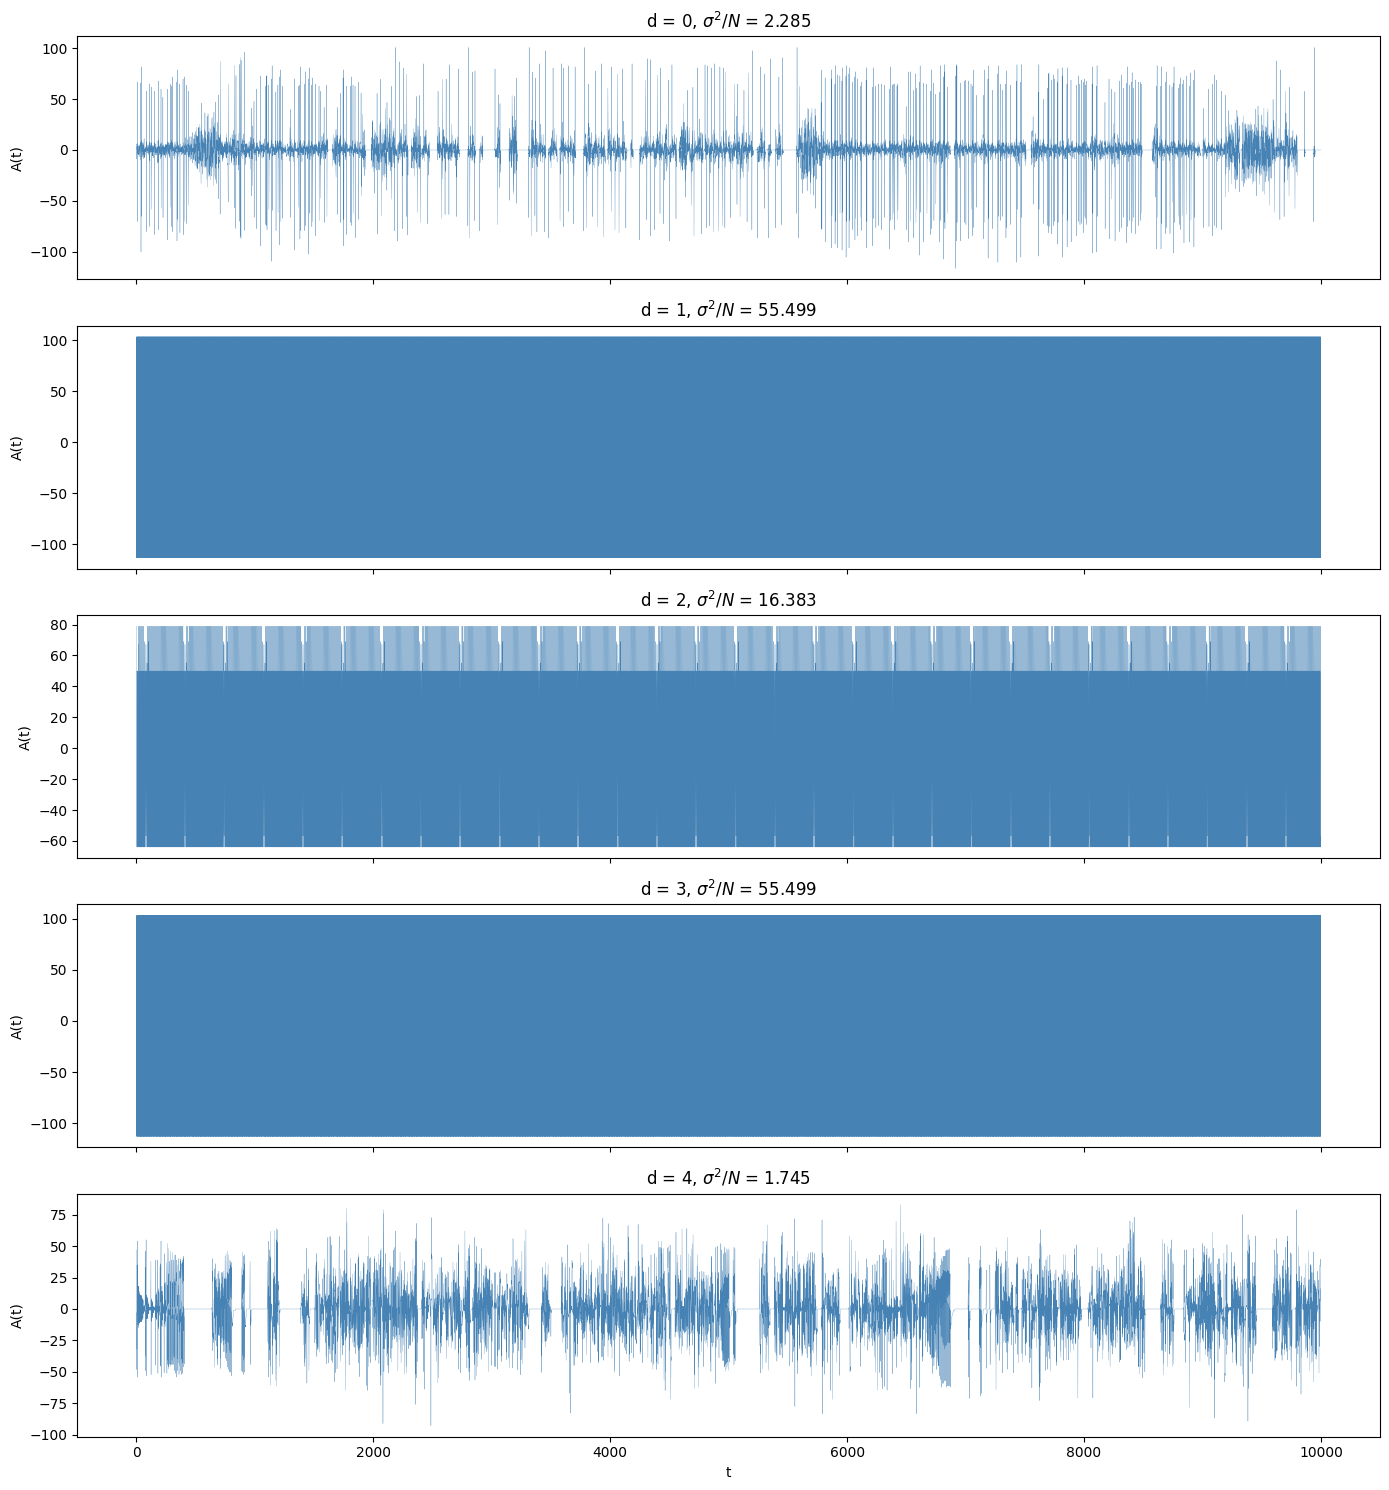

In [10]:
P = 16
N_p = P
N_s = 200
epsilon = 0.01
lam = 0.01
T_phase = int(200 * P / epsilon)
delays = [0, 1, 2, 3, 4]

fig, axes = plt.subplots(len(delays), 1, figsize=(14, 3 * len(delays)), sharex=True)

for idx, d in tqdm(enumerate(delays), desc="Running simulations"):
    np.random.seed(42)
    Omega = np.random.normal(0, np.sqrt(N_p), size=P)
    a = np.random.choice([-1, 1], size=(N_s, P)).astype(np.float64)
    U = np.zeros(N_s)
    mu = np.random.randint(0, P)

    _, _, U, mu = run_minority_delay(a, Omega, U, mu, P, epsilon, lam, d, T_phase)
    A_meas, _, _, _ = run_minority_delay(a, Omega, U, mu, P, epsilon, lam, d, T_phase)

    sigma2 = np.mean(A_meas**2)
    axes[idx].plot(A_meas[:10000], lw=0.2, color='steelblue')
    axes[idx].set_ylabel('A(t)')
    axes[idx].set_title(f'd = {d}, $\\sigma^2/N$ = {sigma2/N_s:.3f}')

axes[-1].set_xlabel('t')
plt.tight_layout()
plt.show()

<blockquote>

For $d=0$, the minority game coordinates normally. Agents learn to anti-correlate with the crowd, which gives low $\sigma^2/N$. 

Introducing a delay breaks this coordination, the delayed strategy values $a_{i, \mu_i(t-d)}$ are anti-correlated with the actions actually taken at time $t$, $a_{i, \mu_i(t)}$, due to the deterministic bit-shift structure of the $\mu$ update rule. This inverts the learning signal, rewarding agents for herding instead of dispersing. $A(t)$ saturates near $\pm N_s$ and $\sigma^2/N$ increases significantly for $d>0$.

For $d=2$, the effect is less pronounced, producing visible oscillations between two states, and $\sigma^2/N$ is smaller than for $d=1$ and $d=3$.

For $d=4$; the delay is long enough that the anti-correlation averages out and we see the expected minority game behavior, though with $\sigma^2/N$ smaller than the $d=0$ case.

</blockquote>

3. En réutilisant le code du TP3.1 tracer les fluctuations $\sigma^2 /N$ et la prévisibilité $H/N$ en fonction de $n_s = N_s / P$ pour $d=0,1,2,3,4$. Commenter la différence des résultats entre les valeurs de $d$.

d=4: 100%|██████████| 12/12 [05:30<00:00, 27.58s/it]


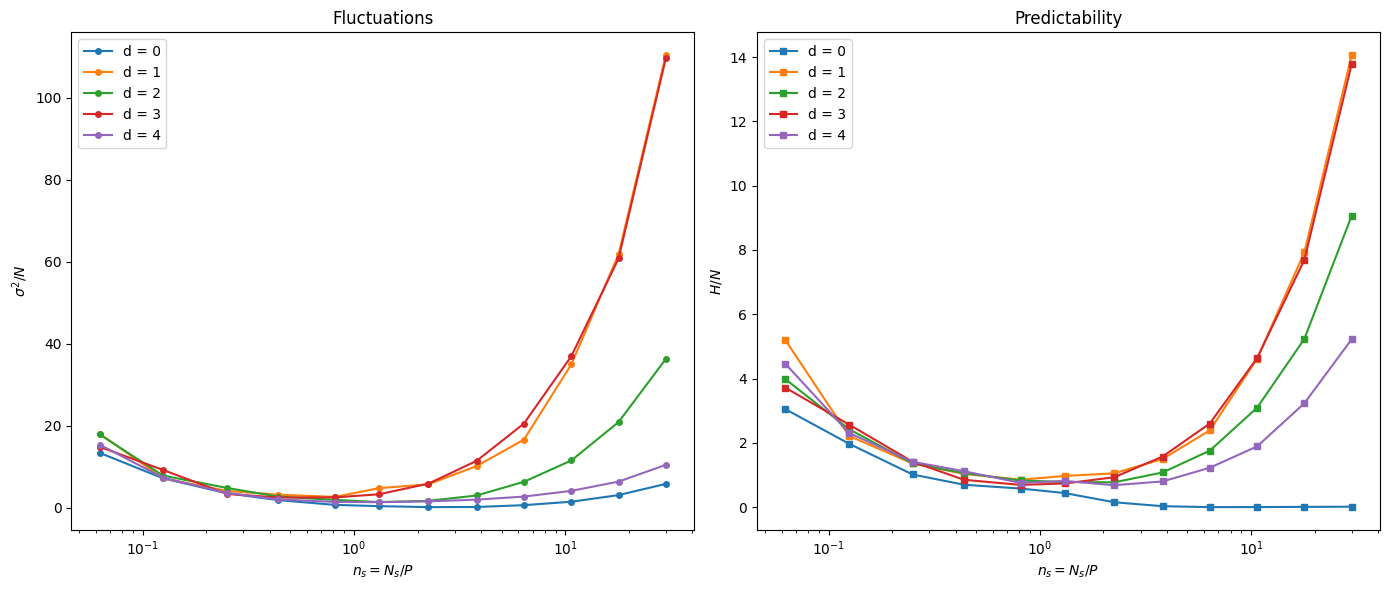

In [11]:
P = 16
N_p = P
epsilon = 0.01
lam = 0.01
n_realizations = 50
T_phase = int(200 * P / epsilon)
delays = [0, 1, 2, 3, 4]

N_s_values = np.unique(np.logspace(np.log10(1), np.log10(30 * P), 13).astype(int))
n_s_values = N_s_values / P

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for d in delays:
    sigma2_arr = np.zeros(len(N_s_values))
    H_arr = np.zeros(len(N_s_values))

    for i, N_s in enumerate(tqdm(N_s_values, desc=f"d={d}")):
        N_s = int(N_s)
        s2_list = np.zeros(n_realizations)
        h_list = np.zeros(n_realizations)

        for r in range(n_realizations):
            Omega = np.random.normal(0, np.sqrt(N_p), size=P)
            a = np.random.choice([-1, 1], size=(N_s, P)).astype(np.float64)
            U = np.zeros(N_s)
            mu = np.random.randint(0, P)

            _, _, U, mu = run_minority_delay(a, Omega, U, mu, P, epsilon, lam, d, T_phase)
            A_meas, mu_meas, _, _ = run_minority_delay(a, Omega, U, mu, P, epsilon, lam, d, T_phase)

            s2_list[r] = np.mean(A_meas**2)
            H = 0.0
            for s in range(P):
                mask = (mu_meas == s)
                if np.any(mask):
                    H += np.mean(A_meas[mask])**2
            h_list[r] = H / P

        sigma2_arr[i] = np.mean(s2_list)
        H_arr[i] = np.mean(h_list)

    axes[0].plot(n_s_values, sigma2_arr / N_s_values, 'o-', label=f'd = {d}', ms=4)
    axes[1].plot(n_s_values, H_arr / N_s_values, 's-', label=f'd = {d}', ms=4)

axes[0].set_xlabel(r'$n_s = N_s / P$')
axes[0].set_ylabel(r'$\sigma^2 / N$')
axes[0].set_xscale('log')
axes[0].legend()
axes[0].set_title('Fluctuations')

axes[1].set_xlabel(r'$n_s = N_s / P$')
axes[1].set_ylabel(r'$H / N$')
axes[1].set_xscale('log')
axes[1].legend()
axes[1].set_title('Predictability')

plt.tight_layout()
plt.show()

<blockquote>

For fluctuations:
- For $d=0$, we have the standard minority game where agents receive immediate feedback on their actions, and the minimum of $\sigma^2/N$ occurs near $n_s \approx 2$. At large $n_s$, $\sigma^2/N$ stays low as many agents still anti-coordinate.
- Odd delays $d=1,3$ progressively break the coordination at large $n_s$, leading to higher $\sigma^2/N$ as agents are rewarded for herding.
- $d=2$ shows intermediate behavior, coordination holds near the minimum but degrades at larger $n_s$.
- $d=4$ is very similar to $d=0$ at large $n_s$ because the delay is long enough that the anti-correlation averages out, but it has a higher $\sigma^2/N$ near the minimum due to less effective learning.

For predictability:
- For $d=0$, $H/N \to 0$ at large $n_s$. The market is unpredictable and agents have learned to erase any exploitable patterns in $A(t)$.
- For all delays $d>0$, the small $n_s$ regime is unaffected by the delay $d$ but $H/N$ diverges at large $n_s$. $d=4$ increases moderately but remains below the other delayed cases. The herding behavior creates strong predictable patterns in $A(t)$, which agents are rewarded for reinforcing. While in the small $n_s$ regime, each $\mu$ is visited infrequently, learning is slow and the delay has little effect.

</blockquote>

---
### 2. Jeu de la majorité : prédictions avec délais

1. Même code qu’à la question 2.1, sauf que l’évolution de son score suit $$U_i (t+1) = U_i(t) (1-\lambda) + \lambda (a_{i, \mu_i(t-d)} A(t) - \epsilon)$$

In [12]:
@njit
def run_majority_delay(a, Omega, U, mu_init, P, epsilon, lam, d, T):
    N_s = a.shape[0]
    A_hist = np.empty(T)
    mu_hist = np.empty(T, dtype=np.int64)
    mu = mu_init

    for t in range(T):
        n = (U >= 0).astype(np.float64)
        A_t = Omega[mu] + np.sum(n * a[:, mu])
        A_hist[t] = A_t
        mu_hist[t] = mu

        if t >= d:
            mu_delayed = mu_hist[t - d]
        else:
            mu_delayed = mu_init

        U[:] = (1 - lam) * U + lam * (a[:, mu_delayed] * A_t - epsilon)
        mu = (2 * mu + int(A_t > 0)) % P

    return A_hist, mu_hist, U, mu

2. Tracer $A(t)$ en fonction de $t$ pour $d=0,1,2,3,4$ et commenter.

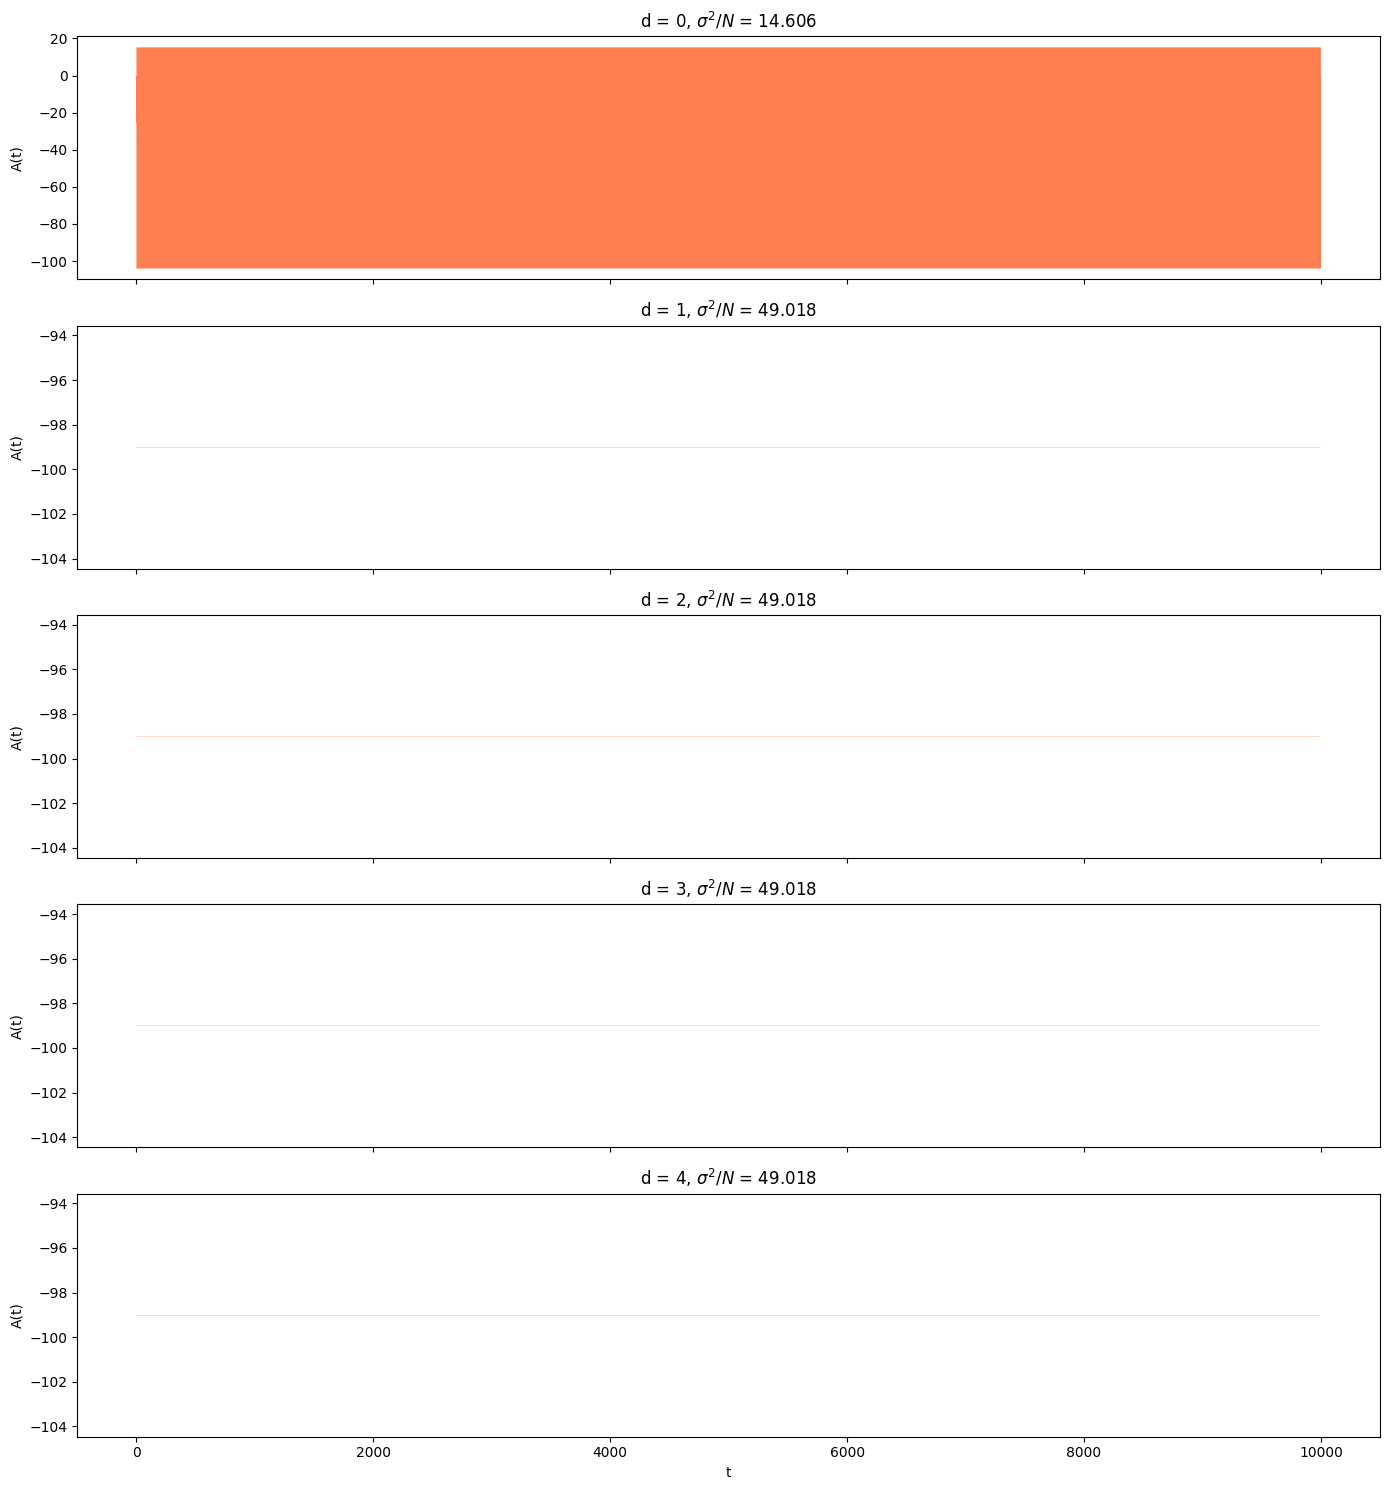

In [13]:
P = 16
N_p = P
N_s = 200
epsilon = 0.01
lam = 0.01
T_phase = int(200 * P / epsilon)
delays = [0, 1, 2, 3, 4]

fig, axes = plt.subplots(len(delays), 1, figsize=(14, 3 * len(delays)), sharex=True)

for idx, d in enumerate(delays):
    np.random.seed(42)
    Omega = np.random.normal(0, np.sqrt(N_p), size=P)
    a = np.random.choice([-1, 1], size=(N_s, P)).astype(np.float64)
    U = np.zeros(N_s)
    mu = np.random.randint(0, P)

    _, _, U, mu = run_majority_delay(a, Omega, U, mu, P, epsilon, lam, d, T_phase)
    A_meas, _, _, _ = run_majority_delay(a, Omega, U, mu, P, epsilon, lam, d, T_phase)

    sigma2 = np.mean(A_meas**2)
    axes[idx].plot(A_meas[:10000], lw=0.2, color='coral')
    axes[idx].set_ylabel('A(t)')
    axes[idx].set_title(f'd = {d}, $\\sigma^2/N$ = {sigma2/N_s:.3f}')

axes[-1].set_xlabel('t')
plt.tight_layout()
plt.show()

<blockquote>

In the majority game, agents are rewarded for herding, so even at $d=0$ we see large fluctuations in $A(t)$ as agents quickly learn to coordinate.

For $d > 0$, the system becomes constant at $A(t) \approx -99  \approx -N_s/2$, with the same $\sigma^2/N$ for all $d>0$. The delay freezes the system, as once all agents coordinate on the same action, the stale feedback offers no incentive to deviate and the state is absorbing. $A(t) \approx -N_s/2$ because only half of the agents, those whose strategies assign $-1$ to the dominant market state remain active.

Unlike the minority game, where delay distorts coordination, in the majority game any delay is sufficient to collapse the system into a fully coordinated fixed state.

</blockquote>

3. En réutilisant le code du TP3.1 tracer les fluctuations $\sigma^2 /N$ et la prévisibilité $H/N$ en fonction de $n_s = N_s / P$ pour $d=0,1,2,3,4$. Commenter la différence des résultats entre les valeurs de $d$.

d=4: 100%|██████████| 12/12 [05:35<00:00, 27.98s/it]


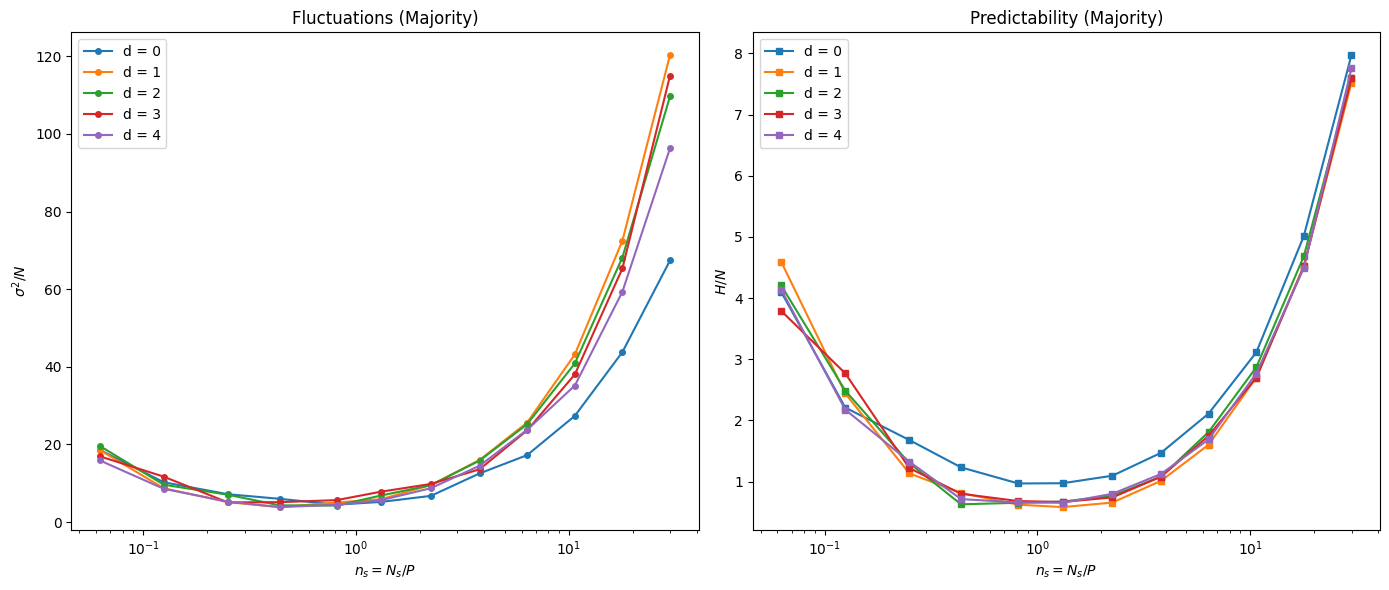

In [14]:
P = 16
N_p = P
epsilon = 0.01
lam = 0.01
n_realizations = 50
T_phase = int(200 * P / epsilon)
delays = [0, 1, 2, 3, 4]

N_s_values = np.unique(np.logspace(np.log10(1), np.log10(30 * P), 13).astype(int))
n_s_values = N_s_values / P

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for d in delays:
    sigma2_arr = np.zeros(len(N_s_values))
    H_arr = np.zeros(len(N_s_values))

    for i, N_s in enumerate(tqdm(N_s_values, desc=f"d={d}")):
        N_s = int(N_s)
        s2_list = np.zeros(n_realizations)
        h_list = np.zeros(n_realizations)

        for r in range(n_realizations):
            Omega = np.random.normal(0, np.sqrt(N_p), size=P)
            a = np.random.choice([-1, 1], size=(N_s, P)).astype(np.float64)
            U = np.zeros(N_s)
            mu = np.random.randint(0, P)

            _, _, U, mu = run_majority_delay(a, Omega, U, mu, P, epsilon, lam, d, T_phase)
            A_meas, mu_meas, _, _ = run_majority_delay(a, Omega, U, mu, P, epsilon, lam, d, T_phase)

            s2_list[r] = np.mean(A_meas**2)
            H = 0.0
            for s in range(P):
                mask = (mu_meas == s)
                if np.any(mask):
                    H += np.mean(A_meas[mask])**2
            h_list[r] = H / P

        sigma2_arr[i] = np.mean(s2_list)
        H_arr[i] = np.mean(h_list)

    axes[0].plot(n_s_values, sigma2_arr / N_s_values, 'o-', label=f'd = {d}', ms=4)
    axes[1].plot(n_s_values, H_arr / N_s_values, 's-', label=f'd = {d}', ms=4)

axes[0].set_xlabel(r'$n_s = N_s / P$')
axes[0].set_ylabel(r'$\sigma^2 / N$')
axes[0].set_xscale('log')
axes[0].legend()
axes[0].set_title('Fluctuations (Majority)')

axes[1].set_xlabel(r'$n_s = N_s / P$')
axes[1].set_ylabel(r'$H / N$')
axes[1].set_xscale('log')
axes[1].legend()
axes[1].set_title('Predictability (Majority)')

plt.tight_layout()
plt.show()

<blockquote>

In the majority game, delay has little effect on either $\sigma^2/N$ or $H/N$. Since agents are already rewarded for herding, the learning signal consistently reinforces coordination. The delay-induced divergence observed in the minority game is absent because the majority game has no anti-coordination mechanism to be disrupted by the delay. Fluctuations and predictability both reach a minimum around $n_s \approx 1$, and grow with $n_s$ for all $d$, due to the crowd size and not the delay.

</blockquote>

4. Comparer vos résultats pour les questions 1.2 et 2.2., ainsi que 1.3 et 2.3.

<blockquote>

Comparing 1.2 and 2.2, the minority game produces coordinated low-variance $A(t)$ at $d=0$, and odd delays invert the learning signal to produce herding and saturation. In the majority game, herding is already the equilibrium behavior at $d=0$, and any delay freezes the system into a constant absorbing state. Delay destabilizes the minority game in a delay-dependent way, and over-stabilizes the majority game immediately.

Comparing 1.3 and 2.3, the minority game shows that $\sigma^2/N$ has a well-defined minimum near $n_s \approx 2$ for $d=0$, and odd delays cause divergence at large $n_s$. In the majority game, all delays collapse onto the same curve. Predictability $H/N \to 0$ at large $n_s$ only in the $d=0$ minority game, and diverges for all $d$ in the majority game. Delay sensitivity is asymmetric between the two games, the minority game is fragile to delay because its equilibrium depends on correctly attributing reward to anti-coordination, while the majority game is robust to delay because herding is already the equilibrium and the delay does not disrupt it.  

</blockquote>